# 07. Entrenamiento de EfficientNetB3 + SE sobre APTOS 2019

Este notebook entrena el segundo modelo candidato para la clasificación
de Retinopatía Diabética: EfficientNetB3 complementada con un bloque
Squeeze-and-Excitation (SE) sobre el mapa de características final.

El entrenamiento utiliza exactamente las mismas condiciones experimentales
definidas para ResNet50:

- mismas particiones Train y Validation;
- mismo tamaño de entrada de 384 × 384 píxeles;
- mismo Data Augmentation;
- mismos pesos de clase;
- mismo tamaño de batch;
- misma función de pérdida;
- mismo criterio de selección de checkpoints.

El entrenamiento se realiza en dos fases:

1. Transfer Learning con el backbone EfficientNetB3 congelado.
2. Fine-Tuning parcial de las capas superiores del backbone.

El conjunto Test permanece completamente aislado.

La comparación posterior entre EfficientNetB3+SE y ResNet50 utilizará
como métrica principal Quadratic Weighted Kappa (QWK) y como métrica
secundaria Macro F1.

## 2. Importación de dependencias del entorno

Se importan las bibliotecas necesarias para la carga y manipulación de datos, el cálculo de métricas de desempeño multiclase y ordinal (QWK, Macro F1), y la construcción de la red convolucional con atención en TensorFlow/Keras.

In [1]:
from pathlib import Path
import json
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)

I0000 00:00:1790755600.110394  262982 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790755600.493556  262982 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790755603.031982  262982 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 3. Definición de rutas del proyecto y persistencia

Se configuran las rutas del proyecto y los directorios de salida para almacenar los checkpoints y registros de evaluación de EfficientNetB3+SE.

In [2]:
PROJECT_ROOT = Path(
    "/mnt/c/Users/SeuNg720/Documents/TP1-RetiScan"
)
APTOS_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "RD"
    / "aptos2019"
)
METADATA_DIR = (
    APTOS_ROOT
    / "metadata"
)
MANIFEST_PATH = (
    METADATA_DIR
    / "aptos2019_processed_manifest.csv"
)
PIPELINE_CONFIG_PATH = (
    PROJECT_ROOT
    / "results"
    / "RD"
    / "training_pipeline"
    / "aptos2019_training_pipeline_config.json"
)
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "RD"
    / "efficientnetb3_se"
)
MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "RD"
    / "efficientnetb3_se"
)
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

### 3.1. Carga de los hiperparámetros comunes del pipeline

Se recupera la configuración congelada desde `aptos2019_training_pipeline_config.json` para garantizar condiciones idénticas de resolución (384 × 384), tamaño de lote (8), semilla aleatoria (42) y ponderación de clases frente al desbalance.

In [3]:
with open(
    PIPELINE_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:
    pipeline_config = json.load(f)

IMAGE_SIZE = int(
    pipeline_config["image_size"][0]
)
BATCH_SIZE = int(
    pipeline_config["batch_size"]
)
RANDOM_SEED = int(
    pipeline_config["random_seed"]
)
NUM_CLASSES = 5
class_weights = {
    int(k): float(v)
    for k, v in pipeline_config[
        "class_weights"
    ].items()
}

tf.keras.utils.set_random_seed(
    RANDOM_SEED
)

print("IMAGE_SIZE:", IMAGE_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("RANDOM_SEED:", RANDOM_SEED)
print("Class weights:", class_weights)

IMAGE_SIZE: 384
BATCH_SIZE: 8
RANDOM_SEED: 42
Class weights: {0: 0.38822593476531425, 1: 2.0677966101694913, 2: 0.7565891472868217, 3: 4.135593220338983, 4: 2.652173913043478}


## 4. Comprobación del acelerador por hardware (GPU)

Se verifica la detección del dispositivo GPU para el cómputo acelerado durante el entrenamiento.

In [4]:
gpus = tf.config.list_physical_devices(
    "GPU"
)
print(
    "GPUs detectadas:",
    gpus
)

GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1790755652.598916  262982 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 5. Carga de particiones experimentales (Train y Validation)

Se lee el manifiesto de imágenes preprocesadas, generando las rutas absolutas para las 2440 observaciones de Train y las 523 de Validation. El conjunto Test (524 imágenes) se conserva estrictamente aislado.

In [5]:
manifest_df = pd.read_csv(
    MANIFEST_PATH
)
manifest_df[
    "absolute_processed_path"
] = manifest_df[
    "processed_path"
].apply(
    lambda x:
        str(APTOS_ROOT / x)
)

train_df = (
    manifest_df[
        manifest_df[
            "experimental_split"
        ] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)
validation_df = (
    manifest_df[
        manifest_df[
            "experimental_split"
        ] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Train:",
    len(train_df)
)
print(
    "Validation:",
    len(validation_df)
)

Train: 2440
Validation: 523


## 6. Pipeline de alimentación con `tf.data`

Se implementa la decodificación de imágenes RGB `float32` a resolución 384 × 384 manteniendo el rango original [0, 255].

In [6]:
def load_image_and_label(
    image_path,
    label
):
    image = tf.io.read_file(
        image_path
    )
    image = tf.image.decode_png(
        image,
        channels=3
    )
    image = tf.cast(
        image,
        tf.float32
    )
    image.set_shape(
        [
            IMAGE_SIZE,
            IMAGE_SIZE,
            3
        ]
    )
    label = tf.cast(
        label,
        tf.int32
    )
    return image, label

### 6.1. Creación de los datasets de Train y Validation

Se configuran los iteradores con barajado dinámico en entrenamiento (`seed=RANDOM_SEED`), batch size de 8 y prefetching en GPU.

In [7]:
def build_dataset(
    dataframe,
    training=False
):
    paths = dataframe[
        "absolute_processed_path"
    ].to_numpy()
    labels = dataframe[
        "diagnosis"
    ].to_numpy(
        dtype=np.int32
    )
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            paths,
            labels
        )
    )
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )
    dataset = dataset.map(
        load_image_and_label,
        num_parallel_calls=2
    )
    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )
    dataset = dataset.prefetch(1)
    return dataset


train_ds = build_dataset(
    train_df,
    training=True
)
validation_ds = build_dataset(
    validation_df,
    training=False
)

W0000 00:00:1790755672.306073  262982 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1790755672.777106  262982 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8568 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:01:00.0, compute capability: 12.0a


## 7. Módulo común de Data Augmentation

Se instancia la misma secuencia de transformaciones geométricas y fotométricas empleada en ResNet50 (volteo horizontal, rotaciones leves, zoom y contraste), para ser ejecutada internamente por la red durante el entrenamiento.

In [8]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal",
            seed=RANDOM_SEED
        ),
        tf.keras.layers.RandomRotation(
            factor=0.03,
            fill_mode="constant",
            fill_value=0.0,
            seed=RANDOM_SEED
        ),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.10, 0.10),
            width_factor=(-0.10, 0.10),
            fill_mode="constant",
            fill_value=0.0,
            seed=RANDOM_SEED
        ),
        tf.keras.layers.RandomContrast(
            factor=0.10,
            seed=RANDOM_SEED
        )
    ],
    name="rd_data_augmentation"
)

## 8. Bloque Squeeze-and-Excitation

Sobre el mapa de características final producido por EfficientNetB3 se
incorpora un bloque Squeeze-and-Excitation.

El bloque resume globalmente la información espacial de cada canal y
aprende coeficientes de atención que permiten reponderar las
características antes de la clasificación final.

Se utiliza un ratio de reducción de 16.

In [9]:
def squeeze_excite_block(
    inputs,
    ratio=16,
    name="se"
):
    channels = int(
        inputs.shape[-1]
    )
    reduced_channels = max(
        channels // ratio,
        1
    )
    x = tf.keras.layers.GlobalAveragePooling2D(
        name=f"{name}_squeeze"
    )(inputs)
    x = tf.keras.layers.Dense(
        reduced_channels,
        activation="relu",
        name=f"{name}_reduce"
    )(x)
    x = tf.keras.layers.Dense(
        channels,
        activation="sigmoid",
        name=f"{name}_expand"
    )(x)
    x = tf.keras.layers.Reshape(
        (1, 1, channels),
        name=f"{name}_reshape"
    )(x)
    return tf.keras.layers.Multiply(
        name=f"{name}_scale"
    )(
        [
            inputs,
            x
        ]
    )

## 9. Arquitectura EfficientNetB3 + SE

EfficientNetB3 preentrenada sobre ImageNet se utiliza como backbone.

Durante Transfer Learning el backbone permanece completamente congelado.

Sobre sus características finales se aplica:

- bloque Squeeze-and-Excitation adicional;
- Global Average Pooling;
- Dropout de 0.30;
- capa Dense de 5 unidades;
- activación Softmax.

In [10]:
tf.keras.backend.clear_session()
gc.collect()

0

### 9.1. Instanciación y congelamiento del backbone EfficientNetB3

Se carga el backbone con pesos de ImageNet sin la cabeza original y se desactiva su entrenabilidad para la fase de Transfer Learning. EfficientNetB3 en TensorFlow/Keras ya incorpora internamente la normalización requerida y recibe directamente imágenes en rango [0, 255].

In [11]:
base_model = (
    tf.keras.applications.EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_shape=(
            IMAGE_SIZE,
            IMAGE_SIZE,
            3
        )
    )
)
base_model.trainable = False

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


### 9.2. Ensamblaje del modelo funcional EfficientNetB3 + SE

Se interconectan la aumentación de datos, el backbone EfficientNetB3 (`training=False`), el bloque de atención de canales Squeeze-and-Excitation (`ratio=16`), pooling espacial global, regularización Dropout (0.30) y la capa densa clasificadora multiclase con activación Softmax.

In [12]:
inputs = tf.keras.Input(
    shape=(
        IMAGE_SIZE,
        IMAGE_SIZE,
        3
    ),
    name="image"
)
x = data_augmentation(
    inputs
)
x = base_model(
    x,
    training=False
)
x = squeeze_excite_block(
    x,
    ratio=16,
    name="additional_se"
)
x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)
x = tf.keras.layers.Dropout(
    0.30,
    name="dropout"
)(x)
outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32",
    name="rd_classification"
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="efficientnetb3_se_rd"
)

### 9.3. Inspección estructural del modelo

Se genera el resumen tabular de la arquitectura para verificar la conectividad de los bloques y las dimensiones intermedias.

In [13]:
model.summary()

Model: "efficientnetb3_se_rd"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 384, 384,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rd_data_augmentati… │ (None, 384, 384,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb3      │ (None, 12, 12,    │ 10,783,535 │ rd_data_augmenta… │
│ (Functional)        │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additional_se_sque… │ (None, 1536)      │          0 │ efficientnetb3[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additional_se_redu… │ (None, 96)        │    147,552 │ additional_se_sq… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additional_se_expa… │ (None, 1536)      │    148,992 │ additional_se_re… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additional_se_resh… │ (None, 1, 1,      │          0 │ additional_se_ex… │
│ (Reshape)           │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additional_se_scale │ (None, 12, 12,    │          0 │ efficientnetb3[0… │
│ (Multiply)          │ 1536)             │            │ additional_se_re… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1536)      │          0 │ additional_se_sc… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1536)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rd_classification   │ (None, 5)         │      7,685 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,087,764 (42.30 MB)

 Trainable params: 304,229 (1.16 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

### 9.4. Verificación y discriminación de parámetros

Se realiza el conteo formal de parámetros para cuantificar la capacidad del modelo e inspeccionar los parámetros entrenables (bloque SE adicional + capa densa) frente a los no entrenables (backbone EfficientNetB3 congelado).

In [14]:
total_params = model.count_params()
trainable_params = sum(
    np.prod(v.shape)
    for v in model.trainable_weights
)
non_trainable_params = (
    total_params
    - trainable_params
)

print(
    "Parámetros totales:",
    f"{total_params:,}"
)
print(
    "Parámetros entrenables:",
    f"{trainable_params:,}"
)
print(
    "Parámetros no entrenables:",
    f"{non_trainable_params:,}"
)

Parámetros totales: 11,087,764
Parámetros entrenables: 304,229
Parámetros no entrenables: 10,783,535


### Recuperación del entorno después de reinicio del kernel

Se reconstruyen las variables, datasets y arquitectura EfficientNetB3+SE
después de un reinicio del kernel.

Esta operación no modifica las condiciones experimentales ni inicia el
entrenamiento.

In [2]:
from pathlib import Path
import json
import gc
import time

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)


# =========================================================
# 1. RUTAS
# =========================================================

PROJECT_ROOT = Path(
    "/mnt/c/Users/SeuNg720/Documents/TP1-RetiScan"
)

APTOS_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "RD"
    / "aptos2019"
)

METADATA_DIR = (
    APTOS_ROOT
    / "metadata"
)

MANIFEST_PATH = (
    METADATA_DIR
    / "aptos2019_processed_manifest.csv"
)

PIPELINE_CONFIG_PATH = (
    PROJECT_ROOT
    / "results"
    / "RD"
    / "training_pipeline"
    / "aptos2019_training_pipeline_config.json"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "RD"
    / "efficientnetb3_se"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "RD"
    / "efficientnetb3_se"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 2. CONFIGURACIÓN CONGELADA
# =========================================================

with open(
    PIPELINE_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:
    pipeline_config = json.load(f)

IMAGE_SIZE = int(
    pipeline_config["image_size"][0]
)

BATCH_SIZE = int(
    pipeline_config["batch_size"]
)

RANDOM_SEED = int(
    pipeline_config["random_seed"]
)

NUM_CLASSES = 5

class_weights = {
    int(k): float(v)
    for k, v in pipeline_config[
        "class_weights"
    ].items()
}

tf.keras.utils.set_random_seed(
    RANDOM_SEED
)


# =========================================================
# 3. DATAFRAME TRAIN / VALIDATION
# =========================================================

manifest_df = pd.read_csv(
    MANIFEST_PATH
)

manifest_df[
    "absolute_processed_path"
] = manifest_df[
    "processed_path"
].apply(
    lambda x:
        str(APTOS_ROOT / x)
)

train_df = (
    manifest_df[
        manifest_df[
            "experimental_split"
        ] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_df = (
    manifest_df[
        manifest_df[
            "experimental_split"
        ] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)


# =========================================================
# 4. TF.DATA
# =========================================================

def load_image_and_label(
    image_path,
    label
):
    image = tf.io.read_file(
        image_path
    )

    image = tf.image.decode_png(
        image,
        channels=3
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image.set_shape(
        [
            IMAGE_SIZE,
            IMAGE_SIZE,
            3
        ]
    )

    label = tf.cast(
        label,
        tf.int32
    )

    return image, label


def build_dataset(
    dataframe,
    training=False
):
    paths = dataframe[
        "absolute_processed_path"
    ].to_numpy()

    labels = dataframe[
        "diagnosis"
    ].to_numpy(
        dtype=np.int32
    )

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                paths,
                labels
            )
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image_and_label,
        num_parallel_calls=2
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    dataset = dataset.prefetch(1)

    return dataset


train_ds = build_dataset(
    train_df,
    training=True
)

validation_ds = build_dataset(
    validation_df,
    training=False
)


# =========================================================
# 5. DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal",
            seed=RANDOM_SEED
        ),

        tf.keras.layers.RandomRotation(
            factor=0.03,
            fill_mode="constant",
            fill_value=0.0,
            seed=RANDOM_SEED
        ),

        tf.keras.layers.RandomZoom(
            height_factor=(-0.10, 0.10),
            width_factor=(-0.10, 0.10),
            fill_mode="constant",
            fill_value=0.0,
            seed=RANDOM_SEED
        ),

        tf.keras.layers.RandomContrast(
            factor=0.10,
            seed=RANDOM_SEED
        )
    ],
    name="rd_data_augmentation"
)


# =========================================================
# 6. BLOQUE SE
# =========================================================

def squeeze_excite_block(
    inputs,
    ratio=16,
    name="se"
):
    channels = int(
        inputs.shape[-1]
    )

    reduced_channels = max(
        channels // ratio,
        1
    )

    x = tf.keras.layers.GlobalAveragePooling2D(
        name=f"{name}_squeeze"
    )(inputs)

    x = tf.keras.layers.Dense(
        reduced_channels,
        activation="relu",
        name=f"{name}_reduce"
    )(x)

    x = tf.keras.layers.Dense(
        channels,
        activation="sigmoid",
        name=f"{name}_expand"
    )(x)

    x = tf.keras.layers.Reshape(
        (1, 1, channels),
        name=f"{name}_reshape"
    )(x)

    return tf.keras.layers.Multiply(
        name=f"{name}_scale"
    )(
        [
            inputs,
            x
        ]
    )


# =========================================================
# 7. RECONSTRUIR EFFICIENTNETB3 + SE
# =========================================================

tf.keras.backend.clear_session()
gc.collect()

base_model = (
    tf.keras.applications.EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_shape=(
            IMAGE_SIZE,
            IMAGE_SIZE,
            3
        )
    )
)

base_model.trainable = False


inputs = tf.keras.Input(
    shape=(
        IMAGE_SIZE,
        IMAGE_SIZE,
        3
    ),
    name="image"
)

x = data_augmentation(
    inputs
)

x = base_model(
    x,
    training=False
)

x = squeeze_excite_block(
    x,
    ratio=16,
    name="additional_se"
)

x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = tf.keras.layers.Dropout(
    0.30,
    name="dropout"
)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32",
    name="rd_classification"
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="efficientnetb3_se_rd"
)


# =========================================================
# 8. VERIFICACIÓN
# =========================================================

total_params = model.count_params()

trainable_params = sum(
    np.prod(v.shape)
    for v in model.trainable_weights
)

non_trainable_params = (
    total_params
    - trainable_params
)

print("IMAGE_SIZE:", IMAGE_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("Train:", len(train_df))
print("Validation:", len(validation_df))

print(
    "Parámetros totales:",
    f"{total_params:,}"
)

print(
    "Parámetros entrenables:",
    f"{trainable_params:,}"
)

print(
    "Parámetros no entrenables:",
    f"{non_trainable_params:,}"
)

print(
    "\nEfficientNetB3 + SE reconstruida correctamente."
)

I0000 00:00:1790756295.356276  264448 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790756296.769905  264448 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790756298.865285  264448 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1790756302.186329  264448 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel bi

IMAGE_SIZE: 384
BATCH_SIZE: 8
Train: 2440
Validation: 523
Parámetros totales: 11,087,764
Parámetros entrenables: 304,229
Parámetros no entrenables: 10,783,535

EfficientNetB3 + SE reconstruida correctamente.


## 10. Fase 1: Transfer Learning

Durante esta fase, el backbone EfficientNetB3 preentrenado sobre ImageNet
permanece completamente congelado.

Se entrenan únicamente el bloque Squeeze-and-Excitation adicional y la
cabeza de clasificación para las cinco categorías de Retinopatía Diabética.

Se utilizan los mismos pesos de clase, Data Augmentation y particiones
empleados en el experimento ResNet50.

El mejor checkpoint se selecciona utilizando la menor pérdida de
Validation (`val_loss`).

### 10.1. Compilación del modelo

Se compila el modelo utilizando el optimizador Adam con una tasa de aprendizaje de 1e-3, la función de pérdida Sparse Categorical Crossentropy y la métrica de exactitud categórica dispersa.

In [4]:
TRANSFER_LR = 1e-3
TRANSFER_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 4

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=TRANSFER_LR
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

### 10.2. Configuración de callbacks y persistencia

Se establecen `ModelCheckpoint` para almacenar el modelo óptimo según el mínimo `val_loss`, `EarlyStopping` con paciencia de 4 épocas para restaurar los mejores pesos y `CSVLogger` para registrar las métricas por epoch.

In [5]:
TRANSFER_MODEL_PATH = (
    MODEL_DIR
    / "efficientnetb3_se_transfer_best.keras"
)
TRANSFER_LOG_PATH = (
    RESULTS_DIR
    / "efficientnetb3_se_transfer_log.csv"
)

transfer_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=TRANSFER_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        TRANSFER_LOG_PATH,
        append=False
    )
]

print(
    "Checkpoint:",
    TRANSFER_MODEL_PATH
)
print(
    "Log:",
    TRANSFER_LOG_PATH
)

Checkpoint: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/efficientnetb3_se/efficientnetb3_se_transfer_best.keras
Log: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/RD/efficientnetb3_se/efficientnetb3_se_transfer_log.csv


### 10.3. Ejecución del entrenamiento de Transfer Learning

Se entrena el modelo sobre `train_ds` con validación en `validation_ds` y ponderación de clases `class_weights`, cronometrando el tiempo total de la fase.

In [6]:
transfer_start = time.time()

transfer_history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=TRANSFER_EPOCHS,
    class_weight=class_weights,
    callbacks=transfer_callbacks,
    verbose=1
)

transfer_end = time.time()
transfer_minutes = (
    transfer_end
    - transfer_start
) / 60

print(
    f"Tiempo Transfer Learning: "
    f"{transfer_minutes:.2f} minutos"
)

Epoch 1/15


/home/seung720/.venvs/retiscan/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790756402.145815  265309 cuda_dnn.cc:461] Loaded cuDNN version 92600


305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6025 - loss: 1.1947
Epoch 1: val_loss improved from None to 0.62065, saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/efficientnetb3_se/efficientnetb3_se_transfer_best.keras

Epoch 1: finished saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/efficientnetb3_se/efficientnetb3_se_transfer_best.keras
305/305 ━━━━━━━━━━━━━━━━━━━━ 40s 82ms/step - accuracy: 0.6025 - loss: 1.1947 - val_accuracy: 0.7878 - val_loss: 0.6207
Epoch 2/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6885 - loss: 0.9948
Epoch 2: val_loss did not improve from 0.62065
305/305 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.6885 - loss: 0.9948 - val_accuracy: 0.7533 - val_loss: 0.6489
Epoch 3/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7303 - loss: 0.9293
Epoch 3: val_loss did not improve from 0.62065
305/305 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.7303 - loss: 0.9293 - val_accuracy: 0.7

### 10.4. Identificación del mejor epoch de Transfer Learning

Se analiza el archivo de registro generado por `CSVLogger` para ubicar la época que alcanzó el menor valor de `val_loss` y su correspondiente exactitud.

In [7]:
transfer_log_df = pd.read_csv(
    TRANSFER_LOG_PATH
)
best_transfer_idx = (
    transfer_log_df[
        "val_loss"
    ].idxmin()
)
best_transfer_row = (
    transfer_log_df.loc[
        best_transfer_idx
    ]
)
best_transfer_epoch = (
    int(
        best_transfer_row[
            "epoch"
        ]
    )
    + 1
)

print(
    "Mejor epoch Transfer:",
    best_transfer_epoch
)
print(
    "val_loss:",
    f"{best_transfer_row['val_loss']:.6f}"
)
print(
    "val_accuracy:",
    f"{best_transfer_row['val_accuracy']:.6f}"
)

Mejor epoch Transfer: 8
val_loss: 0.518798
val_accuracy: 0.785851


### 10.5. Curvas de aprendizaje de Transfer Learning

Se guarda el historial de entrenamiento en disco y se genera la gráfica comparativa de la evolución de la pérdida en entrenamiento y validación.

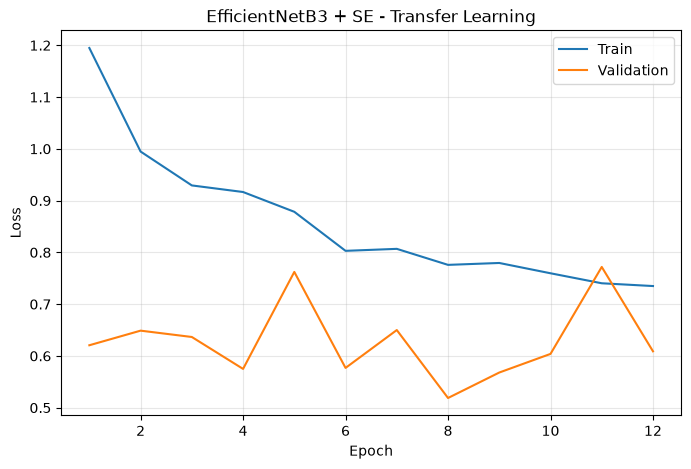

In [8]:
history_df = pd.DataFrame(
    transfer_history.history
)
history_df[
    "epoch"
] = np.arange(
    1,
    len(history_df) + 1
)
history_df.to_csv(
    RESULTS_DIR
    / "efficientnetb3_se_transfer_history.csv",
    index=False
)

plt.figure(
    figsize=(8, 5)
)
plt.plot(
    history_df["epoch"],
    history_df["loss"],
    label="Train"
)
plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "EfficientNetB3 + SE - Transfer Learning"
)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Recuperación del entorno después de reinicio del kernel

Se reconstruyen las variables, rutas y el conjunto Validation necesarios
para evaluar el checkpoint de Transfer Learning previamente almacenado.

No se repite el entrenamiento.

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)


# =========================================================
# 1. RUTAS
# =========================================================

PROJECT_ROOT = Path(
    "/mnt/c/Users/SeuNg720/Documents/TP1-RetiScan"
)

APTOS_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "RD"
    / "aptos2019"
)

METADATA_DIR = (
    APTOS_ROOT
    / "metadata"
)

MANIFEST_PATH = (
    METADATA_DIR
    / "aptos2019_processed_manifest.csv"
)

PIPELINE_CONFIG_PATH = (
    PROJECT_ROOT
    / "results"
    / "RD"
    / "training_pipeline"
    / "aptos2019_training_pipeline_config.json"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "RD"
    / "efficientnetb3_se"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "RD"
    / "efficientnetb3_se"
)

TRANSFER_MODEL_PATH = (
    MODEL_DIR
    / "efficientnetb3_se_transfer_best.keras"
)


# =========================================================
# 2. CONFIGURACIÓN
# =========================================================

with open(
    PIPELINE_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:
    pipeline_config = json.load(f)

IMAGE_SIZE = int(
    pipeline_config["image_size"][0]
)

BATCH_SIZE = int(
    pipeline_config["batch_size"]
)

RANDOM_SEED = int(
    pipeline_config["random_seed"]
)

NUM_CLASSES = 5


# =========================================================
# 3. RECONSTRUIR VALIDATION
# =========================================================

manifest_df = pd.read_csv(
    MANIFEST_PATH
)

manifest_df[
    "absolute_processed_path"
] = manifest_df[
    "processed_path"
].apply(
    lambda x:
        str(APTOS_ROOT / x)
)

validation_df = (
    manifest_df[
        manifest_df[
            "experimental_split"
        ] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)


# =========================================================
# 4. RECONSTRUIR TF.DATA
# =========================================================

def load_image_and_label(
    image_path,
    label
):
    image = tf.io.read_file(
        image_path
    )

    image = tf.image.decode_png(
        image,
        channels=3
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image.set_shape(
        [
            IMAGE_SIZE,
            IMAGE_SIZE,
            3
        ]
    )

    label = tf.cast(
        label,
        tf.int32
    )

    return image, label


def build_dataset(
    dataframe,
    training=False
):
    paths = dataframe[
        "absolute_processed_path"
    ].to_numpy()

    labels = dataframe[
        "diagnosis"
    ].to_numpy(
        dtype=np.int32
    )

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            paths,
            labels
        )
    )

    dataset = dataset.map(
        load_image_and_label,
        num_parallel_calls=2
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    dataset = dataset.prefetch(1)

    return dataset


validation_ds = build_dataset(
    validation_df,
    training=False
)


# =========================================================
# 5. COMPROBACIÓN
# =========================================================

print(
    "Checkpoint existe:",
    TRANSFER_MODEL_PATH.exists()
)

print(
    "Validation:",
    len(validation_df)
)

print(
    "IMAGE_SIZE:",
    IMAGE_SIZE
)

print(
    "BATCH_SIZE:",
    BATCH_SIZE
)

I0000 00:00:1790757062.546654  268119 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790757062.825301  268119 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790757064.743986  268119 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Checkpoint existe: True
Validation: 523
IMAGE_SIZE: 384
BATCH_SIZE: 8


W0000 00:00:1790757067.771735  268119 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1790757067.775626  268119 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1790757068.027046  268119 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9217 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:01:00.0, compute capability: 12.0a


## 11. Evaluación de Transfer Learning sobre Validation

Se evalúa el mejor checkpoint obtenido durante Transfer Learning de
EfficientNetB3+SE utilizando las mismas 523 imágenes del conjunto
Validation utilizadas en el experimento ResNet50.

Las métricas se calculan sobre el conjunto completo:

- Quadratic Weighted Kappa (QWK);
- Macro F1-Score;
- Accuracy;
- Macro Precision;
- Macro Recall;
- matriz de confusión;
- rendimiento individual por clase.

Esta evaluación establece el rendimiento de EfficientNetB3+SE antes
de realizar Fine-Tuning.

### 11.1. Carga explícita del mejor checkpoint de Transfer Learning

Se recarga el modelo guardado en `efficientnetb3_se_transfer_best.keras` sin compilar para garantizar la evaluación exacta de los pesos óptimos de la primera fase.

In [3]:
transfer_model = tf.keras.models.load_model(
    TRANSFER_MODEL_PATH,
    compile=False
)
print(
    "Checkpoint Transfer cargado:",
    TRANSFER_MODEL_PATH
)

Checkpoint Transfer cargado: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/efficientnetb3_se/efficientnetb3_se_transfer_best.keras


### 11.2. Inferencia y alineación de probabilidades sobre Validation

Se generan las probabilidades sobre las 523 imágenes de validación y se extraen las etiquetas reales para la comparación directa.

In [4]:
transfer_probabilities = (
    transfer_model.predict(
        validation_ds,
        verbose=1
    )
)
print(
    "Shape probabilidades:",
    transfer_probabilities.shape
)
print(
    "Suma primera predicción:",
    transfer_probabilities[0].sum()
)

I0000 00:00:1790757106.028821  268532 cuda_dnn.cc:461] Loaded cuDNN version 92600


66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step
Shape probabilidades: (523, 5)
Suma primera predicción: 1.0


### 11.2.1. Extracción de etiquetas reales y clases predichas

Se obtienen las clases predichas con mayor probabilidad (`argmax`) y se verifica la consistencia con las etiquetas reales `y_val`.

In [5]:
y_val = np.concatenate(
    [
        labels.numpy()
        for _, labels
        in validation_ds
    ]
)
y_pred_transfer = np.argmax(
    transfer_probabilities,
    axis=1
)
print(
    "Labels reales:",
    y_val.shape
)
print(
    "Predicciones:",
    y_pred_transfer.shape
)
print(
    "Clases predichas:",
    sorted(
        np.unique(
            y_pred_transfer
        ).tolist()
    )
)

Labels reales: (523,)
Predicciones: (523,)
Clases predichas: [0, 1, 2, 3, 4]


### 11.3. Cálculo de métricas exactas de Transfer Learning

Se computan las métricas de rendimiento global: QWK cuadrático, Macro F1, exactitud, Macro Precision, Macro Recall y la matriz de confusión multiclase.

In [6]:
transfer_qwk = cohen_kappa_score(
    y_val,
    y_pred_transfer,
    weights="quadratic"
)
transfer_macro_f1 = f1_score(
    y_val,
    y_pred_transfer,
    average="macro",
    zero_division=0
)
transfer_accuracy = accuracy_score(
    y_val,
    y_pred_transfer
)
transfer_macro_precision = precision_score(
    y_val,
    y_pred_transfer,
    average="macro",
    zero_division=0
)
transfer_macro_recall = recall_score(
    y_val,
    y_pred_transfer,
    average="macro",
    zero_division=0
)
transfer_cm = confusion_matrix(
    y_val,
    y_pred_transfer,
    labels=[0, 1, 2, 3, 4]
)

print(
    f"QWK:             "
    f"{transfer_qwk:.6f}"
)
print(
    f"Macro F1:        "
    f"{transfer_macro_f1:.6f}"
)
print(
    f"Accuracy:        "
    f"{transfer_accuracy:.6f}"
)
print(
    f"Macro Precision: "
    f"{transfer_macro_precision:.6f}"
)
print(
    f"Macro Recall:    "
    f"{transfer_macro_recall:.6f}"
)
print(
    "\nMatriz de confusión:"
)
print(
    transfer_cm
)

QWK:             0.871645
Macro F1:        0.577172
Accuracy:        0.785851
Macro Precision: 0.649846
Macro Recall:    0.588370

Matriz de confusión:
[[262   7   0   0   0]
 [  5  30  15   0   1]
 [  2  24 100  12   0]
 [  0   0  12  12   1]
 [  0   1  20  12   7]]


### 11.4. Reporte de clasificación por categoría diagnóstica

Se evalúa la precisión, recall y F1-score discriminados por cada grado de severidad clínica en Validation, con especial atención a las categorías minoritarias.

In [7]:
transfer_report = classification_report(
    y_val,
    y_pred_transfer,
    labels=[0, 1, 2, 3, 4],
    target_names=[
        "Sin RD",
        "Leve",
        "Moderada",
        "Severa",
        "Proliferativa"
    ],
    output_dict=True,
    zero_division=0
)
transfer_report_df = (
    pd.DataFrame(
        transfer_report
    )
    .transpose()
)
display(
    transfer_report_df.round(4)
)

,precision,recall,f1-score,support
Sin RD,0.9740,0.9740,0.9740,269.0000
Leve,0.4839,0.5882,0.5310,51.0000
Moderada,0.6803,0.7246,0.7018,138.0000
Severa,0.3333,0.4800,0.3934,25.0000
Proliferativa,0.7778,0.1750,0.2857,40.0000
accuracy,0.7859,0.7859,0.7859,0.7859
macro avg,0.6498,0.5884,0.5772,523.0000
weighted avg,0.8031,0.7859,0.7786,523.0000


### 11.5. Persistencia de predicciones de Validation

Se exportan las probabilidades y la clase predicha por muestra a un archivo CSV para la comparación multi-modelo.

In [8]:
transfer_validation_results = (
    validation_df[
        [
            "id_code",
            "diagnosis"
        ]
    ]
    .copy()
)
transfer_validation_results[
    "predicted_class"
] = y_pred_transfer

for class_id in range(
    NUM_CLASSES
):
    transfer_validation_results[
        f"score_class_{class_id}"
    ] = (
        transfer_probabilities[
            :,
            class_id
        ]
    )

TRANSFER_VALIDATION_PATH = (
    RESULTS_DIR
    / "efficientnetb3_se_transfer_validation_predictions.csv"
)
transfer_validation_results.to_csv(
    TRANSFER_VALIDATION_PATH,
    index=False
)

### 11.5.1. Resumen tabular de métricas de Transfer Learning

Se estructura y persiste el resumen de métricas globales de la primera fase de EfficientNetB3+SE en disco.

In [9]:
transfer_metrics_df = pd.DataFrame(
    {
        "metric": [
            "QWK",
            "Macro F1",
            "Accuracy",
            "Macro Precision",
            "Macro Recall"
        ],
        "value": [
            transfer_qwk,
            transfer_macro_f1,
            transfer_accuracy,
            transfer_macro_precision,
            transfer_macro_recall
        ]
    }
)
display(
    transfer_metrics_df.round(6)
)
transfer_metrics_df.to_csv(
    RESULTS_DIR
    / "efficientnetb3_se_transfer_metrics.csv",
    index=False
)

,metric,value
0,QWK,0.871645
1,Macro F1,0.577172
2,Accuracy,0.785851
3,Macro Precision,0.649846
4,Macro Recall,0.588370


## 12. Preparación del Fine-Tuning

Antes de definir qué parte del backbone EfficientNetB3 será desbloqueada,
se inspeccionan sus capas finales.

El objetivo es identificar el último bloque semántico de la arquitectura
y realizar un Fine-Tuning parcial comparable al aplicado previamente
sobre ResNet50.

Las capas Batch Normalization permanecerán congeladas durante esta fase.

### 12.1. Recuperación del backbone EfficientNetB3

Se extrae la capa base preentrenada `efficientnetb3` desde el modelo cargado para inspeccionar su estructura y número total de capas.

In [10]:
base_model = transfer_model.get_layer(
    "efficientnetb3"
)
print(
    "Backbone:",
    base_model.name
)
print(
    "Número de capas:",
    len(base_model.layers)
)

Backbone: efficientnetb3
Número de capas: 385


### 12.2. Inspección de la topología final del backbone

Se listan los nombres y tipos de las últimas 40 capas del backbone para identificar con precisión los límites del bloque superior (como `block7` y capas `top_`).

In [11]:
for layer in base_model.layers[-40:]:
    print(
        layer.name,
        "|",
        layer.__class__.__name__
    )

block6f_se_squeeze | GlobalAveragePooling2D
block6f_se_reshape | Reshape
block6f_se_reduce | Conv2D
block6f_se_expand | Conv2D
block6f_se_excite | Multiply
block6f_project_conv | Conv2D
block6f_project_bn | BatchNormalization
block6f_drop | Dropout
block6f_add | Add
block7a_expand_conv | Conv2D
block7a_expand_bn | BatchNormalization
block7a_expand_activation | Activation
block7a_dwconv | DepthwiseConv2D
block7a_bn | BatchNormalization
block7a_activation | Activation
block7a_se_squeeze | GlobalAveragePooling2D
block7a_se_reshape | Reshape
block7a_se_reduce | Conv2D
block7a_se_expand | Conv2D
block7a_se_excite | Multiply
block7a_project_conv | Conv2D
block7a_project_bn | BatchNormalization
block7b_expand_conv | Conv2D
block7b_expand_bn | BatchNormalization
block7b_expand_activation | Activation
block7b_dwconv | DepthwiseConv2D
block7b_bn | BatchNormalization
block7b_activation | Activation
block7b_se_squeeze | GlobalAveragePooling2D
block7b_se_reshape | Reshape
block7b_se_reduce | Conv2D

### 12.1. Descongelamiento del último bloque de EfficientNetB3

Para el Fine-Tuning se habilita el entrenamiento del último bloque
semántico de EfficientNetB3 (`block7`) y de la convolución superior
(`top_conv`).

Las capas anteriores permanecen congeladas y todas las capas
Batch Normalization se mantienen no entrenables.

El bloque Squeeze-and-Excitation adicional y la cabeza de clasificación
continúan siendo entrenables.

In [12]:
base_model.trainable = True
for layer in base_model.layers:
    if (
        layer.name.startswith("block7")
        or
        layer.name.startswith("top_")
    ):
        layer.trainable = True
    else:
        layer.trainable = False
    # Batch Normalization siempre congelada
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

### 12.2. Verificación de capas entrenables del backbone

Se comprueba la lista exhaustiva de capas activadas en el backbone, verificando que pertenezcan unívocamente a `block7` o convoluciones `top_`, y que ninguna capa `top_bn` o de normalización esté habilitada.

In [13]:
trainable_backbone_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]
print(
    "Capas entrenables del backbone:",
    len(trainable_backbone_layers)
)
print(
    "\nCapas entrenables:"
)
for layer_name in trainable_backbone_layers:
    print(layer_name)

Capas entrenables del backbone: 24

Capas entrenables:
block7a_expand_conv
block7a_expand_activation
block7a_dwconv
block7a_activation
block7a_se_squeeze
block7a_se_reshape
block7a_se_reduce
block7a_se_expand
block7a_se_excite
block7a_project_conv
block7b_expand_conv
block7b_expand_activation
block7b_dwconv
block7b_activation
block7b_se_squeeze
block7b_se_reshape
block7b_se_reduce
block7b_se_expand
block7b_se_excite
block7b_project_conv
block7b_drop
block7b_add
top_conv
top_activation


### 12.3. Conteo de parámetros entrenables para Fine-Tuning

Se recalcula la cantidad de parámetros entrenables del modelo global para contrastar el incremento respecto a la fase de Transfer Learning.

In [14]:
total_params_ft = (
    transfer_model.count_params()
)
trainable_params_ft = sum(
    np.prod(v.shape)
    for v in transfer_model.trainable_weights
)
non_trainable_params_ft = (
    total_params_ft
    - trainable_params_ft
)

print(
    "Parámetros totales:",
    f"{total_params_ft:,}"
)
print(
    "Parámetros entrenables:",
    f"{trainable_params_ft:,}"
)
print(
    "Parámetros no entrenables:",
    f"{non_trainable_params_ft:,}"
)

Parámetros totales: 11,087,764
Parámetros entrenables: 4,161,951
Parámetros no entrenables: 6,925,813


## 13. Reconstrucción preventiva de Train y ponderación de clases

Se reconstruyen los datasets y el diccionario de pesos de clase a partir del manifiesto para garantizar que el entrenamiento se ejecute sobre el conjunto completo de 2440 imágenes de Train.

In [15]:
class_weights = {
    int(k): float(v)
    for k, v in pipeline_config[
        "class_weights"
    ].items()
}
train_df = (
    manifest_df[
        manifest_df[
            "experimental_split"
        ] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)
train_ds = build_dataset(
    train_df,
    training=True
)

print(
    "Train:",
    len(train_df)
)
print(
    "Validation:",
    len(validation_df)
)
print(
    "Class weights:",
    class_weights
)

Train: 2440
Validation: 523
Class weights: {0: 0.38822593476531425, 1: 2.0677966101694913, 2: 0.7565891472868217, 3: 4.135593220338983, 4: 2.652173913043478}


## 14. Fase 2: Fine-Tuning parcial de EfficientNetB3 + SE

Se recompila el modelo con una tasa de aprendizaje reducida de `1e-5`, conservando el optimizador Adam y la pérdida Sparse Categorical Crossentropy para ajustes finos sobre los pesos descongelados.

In [16]:
FINETUNE_LR = 1e-5
FINETUNE_EPOCHS = 15
FINETUNE_PATIENCE = 4

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINETUNE_LR
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print(
    "Learning rate Fine-Tuning:",
    FINETUNE_LR
)
print(
    "Máximo de epochs:",
    FINETUNE_EPOCHS
)

Learning rate Fine-Tuning: 1e-05
Máximo de epochs: 15


### 14.1. Callbacks de Fine-Tuning

Se configuran `ModelCheckpoint` guardando el mejor checkpoint en `models/RD/efficientnetb3_se/efficientnetb3_se_finetune_best.keras`, `EarlyStopping` con paciencia de 4 épocas y `CSVLogger` para registrar las métricas por época.

In [17]:
FINETUNE_MODEL_PATH = (
    MODEL_DIR
    / "efficientnetb3_se_finetune_best.keras"
)
FINETUNE_LOG_PATH = (
    RESULTS_DIR
    / "efficientnetb3_se_finetune_log.csv"
)

finetune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=FINETUNE_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=FINETUNE_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        FINETUNE_LOG_PATH,
        append=False
    )
]

print(
    "Checkpoint Fine-Tuning:",
    FINETUNE_MODEL_PATH
)

Checkpoint Fine-Tuning: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/efficientnetb3_se/efficientnetb3_se_finetune_best.keras


### 14.2. Ejecución del entrenamiento de Fine-Tuning

Se ejecuta el ajuste fino de la red sobre `train_ds` con validación en `validation_ds` y ponderación de clases `class_weights`, midiendo el tiempo de cómputo.

In [18]:
import time

finetune_start = time.time()

finetune_history = transfer_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=FINETUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=finetune_callbacks,
    verbose=1
)

finetune_end = time.time()
finetune_minutes = (
    finetune_end
    - finetune_start
) / 60

print(
    f"Tiempo Fine-Tuning: "
    f"{finetune_minutes:.2f} minutos"
)

Epoch 1/15


/home/seung720/.venvs/retiscan/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
E0000 00:00:1790757769.716660  268119 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb3_se_rd_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7885 - loss: 0.7531
Epoch 1: val_loss improved from None to 0.57696, saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/efficientnetb3_se/efficientnetb3_se_finetune_best.keras

Epoch 1: finished saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/efficientnetb3_se/efficientnetb3_se_finetune_best.keras
305/305 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.7885 - loss: 0.7531 - val_accuracy: 0.7801 - val_loss: 0.5770
Epoch 2/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7951 - loss: 0.7202
Epoch 2: val_loss did not improve from 0.57696
305/305 ━━━━━━━━━━━━━━━━━━━━ 23s 76ms/step - accuracy: 0.7951 - loss: 0.7202 - val_accuracy: 0.7648 - val_loss: 0.5972
Epoch 3/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7963 - loss: 0.7072
Epoch 3: val_loss did not improve from 0.57696
305/305 ━━━━━━━━━━━━━━━━━━━━ 23s 76ms/step - accuracy: 0.7963 - loss: 0.7072 - val_accuracy: 0.7

### 14.3. Identificación del mejor epoch de Fine-Tuning

Se analiza el archivo de registro `efficientnetb3_se_finetune_log.csv` para reportar el epoch que obtuvo la menor pérdida de validación y la exactitud asociada.

In [19]:
finetune_log_df = pd.read_csv(
    FINETUNE_LOG_PATH
)
best_finetune_idx = (
    finetune_log_df[
        "val_loss"
    ].idxmin()
)
best_finetune_row = (
    finetune_log_df.loc[
        best_finetune_idx
    ]
)
best_finetune_epoch = (
    int(
        best_finetune_row["epoch"]
    )
    + 1
)

print(
    "Mejor epoch Fine-Tuning:",
    best_finetune_epoch
)
print(
    "val_loss:",
    f"{best_finetune_row['val_loss']:.6f}"
)
print(
    "val_accuracy:",
    f"{best_finetune_row['val_accuracy']:.6f}"
)

Mejor epoch Fine-Tuning: 1
val_loss: 0.576958
val_accuracy: 0.780115


## 15. Evaluación del Fine-Tuning sobre Validation

Se evalúa el mejor checkpoint obtenido durante Fine-Tuning sobre las
mismas 523 imágenes de Validation.

Los resultados se comparan directamente con la fase de Transfer Learning
utilizando las métricas predefinidas: QWK como criterio principal y
Macro F1 como criterio secundario.

### 15.1. Carga explícita del mejor checkpoint de Fine-Tuning

Se carga directamente el modelo guardado `efficientnetb3_se_finetune_best.keras` sin compilar para garantizar la evaluación exacta de los pesos seleccionados por menor `val_loss`.

In [20]:
finetune_model = tf.keras.models.load_model(
    FINETUNE_MODEL_PATH,
    compile=False
)
print(
    "Checkpoint Fine-Tuning cargado:",
    FINETUNE_MODEL_PATH
)

Checkpoint Fine-Tuning cargado: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/efficientnetb3_se/efficientnetb3_se_finetune_best.keras


### 15.2. Inferencia y alineación de probabilidades sobre Validation

Se obtienen las distribuciones de probabilidad predichas sobre las 523 imágenes de validación y se extraen las predicciones finales con `argmax`.

In [21]:
finetune_probabilities = (
    finetune_model.predict(
        validation_ds,
        verbose=1
    )
)
y_pred_finetune = np.argmax(
    finetune_probabilities,
    axis=1
)

if "y_val" not in globals():
    y_val = np.concatenate(
        [
            labels.numpy()
            for _, labels
            in validation_ds
        ]
    )

print(
    "Shape probabilidades:",
    finetune_probabilities.shape
)
print(
    "Predicciones:",
    y_pred_finetune.shape
)
print(
    "Clases predichas:",
    sorted(
        np.unique(
            y_pred_finetune
        ).tolist()
    )
)

66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step
Shape probabilidades: (523, 5)
Predicciones: (523,)
Clases predichas: [0, 1, 2, 3, 4]


### 15.3. Cálculo de métricas exactas de Fine-Tuning

Se evalúan las métricas consolidadas: QWK con ponderación cuadrática, Macro F1, exactitud global, Macro Precision, Macro Recall y matriz de confusión multiclase.

In [22]:
finetune_qwk = cohen_kappa_score(
    y_val,
    y_pred_finetune,
    weights="quadratic"
)
finetune_macro_f1 = f1_score(
    y_val,
    y_pred_finetune,
    average="macro",
    zero_division=0
)
finetune_accuracy = accuracy_score(
    y_val,
    y_pred_finetune
)
finetune_macro_precision = precision_score(
    y_val,
    y_pred_finetune,
    average="macro",
    zero_division=0
)
finetune_macro_recall = recall_score(
    y_val,
    y_pred_finetune,
    average="macro",
    zero_division=0
)
finetune_cm = confusion_matrix(
    y_val,
    y_pred_finetune,
    labels=[0, 1, 2, 3, 4]
)

print(
    f"QWK:             {finetune_qwk:.6f}"
)
print(
    f"Macro F1:        {finetune_macro_f1:.6f}"
)
print(
    f"Accuracy:        {finetune_accuracy:.6f}"
)
print(
    f"Macro Precision: {finetune_macro_precision:.6f}"
)
print(
    f"Macro Recall:    {finetune_macro_recall:.6f}"
)
print(
    "\nMatriz de confusión:"
)
print(
    finetune_cm
)

QWK:             0.877946
Macro F1:        0.618500
Accuracy:        0.780115
Macro Precision: 0.643499
Macro Recall:    0.648837

Matriz de confusión:
[[257  12   0   0   0]
 [  3  38   8   0   2]
 [  1  33  84  19   1]
 [  0   0   8  14   3]
 [  0   4   9  12  15]]


### 15.4. Reporte detallado por clase de severidad

Se genera el reporte de clasificación para inspeccionar el impacto del Fine-Tuning en la discriminación de cada una de las 5 categorías diagnósticas de retinopatía.

In [23]:
finetune_report = classification_report(
    y_val,
    y_pred_finetune,
    labels=[0, 1, 2, 3, 4],
    target_names=[
        "Sin RD",
        "Leve",
        "Moderada",
        "Severa",
        "Proliferativa"
    ],
    output_dict=True,
    zero_division=0
)
finetune_report_df = (
    pd.DataFrame(
        finetune_report
    )
    .transpose()
)
display(
    finetune_report_df.round(4)
)

,precision,recall,f1-score,support
Sin RD,0.9847,0.9554,0.9698,269.0000
Leve,0.4368,0.7451,0.5507,51.0000
Moderada,0.7706,0.6087,0.6802,138.0000
Severa,0.3111,0.5600,0.4000,25.0000
Proliferativa,0.7143,0.3750,0.4918,40.0000
accuracy,0.7801,0.7801,0.7801,0.7801
macro avg,0.6435,0.6488,0.6185,523.0000
weighted avg,0.8219,0.7801,0.7887,523.0000


### 15.5. Persistencia de predicciones de Validation en Fine-Tuning

Se almacenan los vectores de probabilidad y la clase predicha para cada observación de Validation en formato CSV para su posterior integración en el análisis comparativo.

In [24]:
finetune_validation_results = (
    validation_df[
        [
            "id_code",
            "diagnosis"
        ]
    ]
    .copy()
)
finetune_validation_results[
    "predicted_class"
] = y_pred_finetune

for class_id in range(
    NUM_CLASSES
):
    finetune_validation_results[
        f"score_class_{class_id}"
    ] = (
        finetune_probabilities[
            :,
            class_id
        ]
    )

FINETUNE_VALIDATION_PATH = (
    RESULTS_DIR
    / "efficientnetb3_se_finetune_validation_predictions.csv"
)
finetune_validation_results.to_csv(
    FINETUNE_VALIDATION_PATH,
    index=False
)
print(
    "Predicciones de Fine-Tuning guardadas en:",
    FINETUNE_VALIDATION_PATH
)

Predicciones de Fine-Tuning guardadas en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/RD/efficientnetb3_se/efficientnetb3_se_finetune_validation_predictions.csv


### 15.6. Comparación directa Transfer Learning vs. Fine-Tuning

Se consolida la tabla comparativa del rendimiento de EfficientNetB3+SE entre la fase de Transfer Learning y la fase de Fine-Tuning parcial.

In [25]:
efficientnet_comparison_df = pd.DataFrame(
    {
        "Transfer Learning": {
            "QWK":
                transfer_qwk,
            "Macro F1":
                transfer_macro_f1,
            "Accuracy":
                transfer_accuracy,
            "Macro Precision":
                transfer_macro_precision,
            "Macro Recall":
                transfer_macro_recall
        },
        "Fine-Tuning": {
            "QWK":
                finetune_qwk,
            "Macro F1":
                finetune_macro_f1,
            "Accuracy":
                finetune_accuracy,
            "Macro Precision":
                finetune_macro_precision,
            "Macro Recall":
                finetune_macro_recall
        }
    }
)
display(
    efficientnet_comparison_df.round(6)
)
efficientnet_comparison_df.to_csv(
    RESULTS_DIR
    / "efficientnetb3_se_comparison.csv"
)

,Transfer Learning,Fine-Tuning
QWK,0.871645,0.877946
Macro F1,0.577172,0.618500
Accuracy,0.785851,0.780115
Macro Precision,0.649846,0.643499
Macro Recall,0.588370,0.648837


### 15.7. Persistencia de métricas y reporte de Fine-Tuning

Se exportan las métricas finales y el reporte de clasificación de Fine-Tuning a disco.

In [26]:
finetune_metrics_df = pd.DataFrame(
    {
        "metric": [
            "QWK",
            "Macro F1",
            "Accuracy",
            "Macro Precision",
            "Macro Recall"
        ],
        "value": [
            finetune_qwk,
            finetune_macro_f1,
            finetune_accuracy,
            finetune_macro_precision,
            finetune_macro_recall
        ]
    }
)
finetune_metrics_df.to_csv(
    RESULTS_DIR
    / "efficientnetb3_se_finetune_metrics.csv",
    index=False
)
finetune_report_df.to_csv(
    RESULTS_DIR
    / "efficientnetb3_se_finetune_classification_report.csv"
)
print(
    "Métricas de Fine-Tuning guardadas."
)

Métricas de Fine-Tuning guardadas.


### 15.8. Persistencia de la matriz de confusión de Fine-Tuning

Se estructura la matriz de confusión multiclase en un DataFrame con nombres de clase informativos y se exporta a formato CSV.

In [27]:
efficientnet_cm_df = pd.DataFrame(
    finetune_cm,
    index=[
        "True_0",
        "True_1",
        "True_2",
        "True_3",
        "True_4"
    ],
    columns=[
        "Pred_0",
        "Pred_1",
        "Pred_2",
        "Pred_3",
        "Pred_4"
    ]
)
efficientnet_cm_df.to_csv(
    RESULTS_DIR
    / "efficientnetb3_se_finetune_confusion_matrix.csv"
)
display(
    efficientnet_cm_df
)

,Pred_0,Pred_1,Pred_2,Pred_3,Pred_4
True_0,257,12,0,0,0
True_1,3,38,8,0,2
True_2,1,33,84,19,1
True_3,0,0,8,14,3
True_4,0,4,9,12,15


## 16. Conclusiones del experimento EfficientNetB3+SE

EfficientNetB3+SE fue entrenada mediante Transfer Learning y posteriormente
ajustada mediante Fine-Tuning parcial del bloque `block7` y de las capas
superiores del backbone, manteniendo congeladas las capas Batch
Normalization.

Durante Transfer Learning, el mejor checkpoint fue obtenido en la época 8,
con una pérdida de Validation de 0.518798 y una Accuracy de 0.785851.

Durante Fine-Tuning, el mejor checkpoint fue obtenido en la época 1, con
una pérdida de Validation de 0.576958 y una Accuracy de 0.780115.

Aunque la pérdida y la Accuracy no mejoraron respecto a Transfer Learning,
la evaluación exacta sobre Validation mostró una mejora en las métricas
predefinidas para la selección experimental.

El checkpoint de Fine-Tuning obtuvo:

- QWK: 0.877946.
- Macro F1: 0.618500.
- Accuracy: 0.780115.
- Macro Precision: 0.643499.
- Macro Recall: 0.648837.

Respecto a Transfer Learning, Fine-Tuning incrementó QWK en 0.006301 y
Macro F1 en 0.041328.

Por tanto, el checkpoint de Fine-Tuning se conserva como la representación
final de EfficientNetB3+SE para su comparación contra ResNet50.

El conjunto Test no fue utilizado durante este experimento.